# Basic Data Cleaning

**Dataset:** https://www.kaggle.com/datasets/yasserh/titanic-dataset

The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone on board, resulting in the death of 1502 out of 2224 passengers and crew. The dataset contains the information about some of the passengers who were abroad the Titanic during its sinking.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Data

In [2]:
df = pd.read_csv("../data/Titanic-Dataset.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## Checking for Duplicates

In [5]:
df.duplicated().any()

np.False_

Duplicate rows can skew the learning process. If the same data point appears multiple times, the model may treat it as more important than it really is. We would rather drop these.

In [6]:
df.drop_duplicates(inplace=True)

**NOTE:** Some functions return a new dataframe instead of modifying the original one. Using `inplace=True` means that we will modify the original dataframe instead of creating a new one.

## Handling Missing Values



Missing values are also a problem.

Most ML algorithms cannot handle undefined values i.e NaN. If there are any missing values in the dataset we typically handle them by:

- **Dropping rows/columns** (if the proportion of missing values is small or irrelevant)

- **Imputing values** using statistical techniques (mean, median, mode, etc.)

In [7]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

From, what we can see, the `Age`, `Embarked` and `Cabin` columns have missing values.

We will drop the `Cabin` column since it has too many missing values (687 out of 891 values are missing).

In [8]:
df.drop(columns=["Cabin"], inplace=True)

In [9]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


We can fill the missing values in the Age column with the median age of the passengers.

In [10]:
median_age = df["Age"].median()

df["Age"] = df["Age"].fillna(median_age)

The remaining missing values are in the `Embarked` column, which is a categorical variable. We can fill the missing values with the mode of the column or drop the rows with missing values. We will drop those rows.

In [11]:
df.dropna(inplace=True)

We called `dropna()` to remove any remaining rows with missing values. This is a common practice in data cleaning, especially when the number of missing values is small compared to the size of the dataset. However, it is important to consider the implications of dropping data, as it can lead to loss of information. In some cases, it might be better to impute missing values or use other techniques to handle them.

## Exploratory Data Analysis

EDA is the first step in a data science or machine learning project. It involves exploring, visualizing, and summarizing your data to understand what is in the dataset, what problems or patterns are there and what steps are needed before modeling. Common Steps are:

- Understand the structure of the dataset
- Check for missing values and duplicate rows
- Visualize distributions
- Check for correlations
- Visualize relationships
- Outlier detection

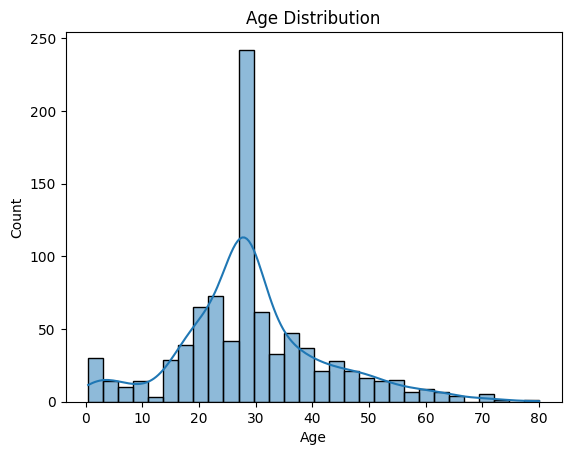

In [12]:
# Visualize the distribution of the "Age" column
sns.histplot(data=df, x="Age", bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

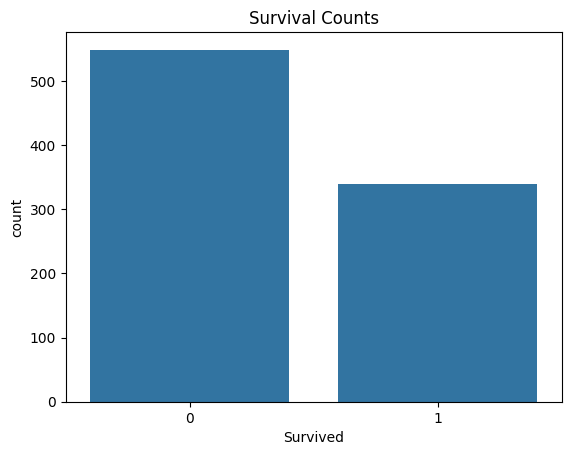

In [13]:
# Visualize the distribution of the "Survived" column
sns.countplot(data=df, x="Survived")
plt.title("Survival Counts")
plt.show()

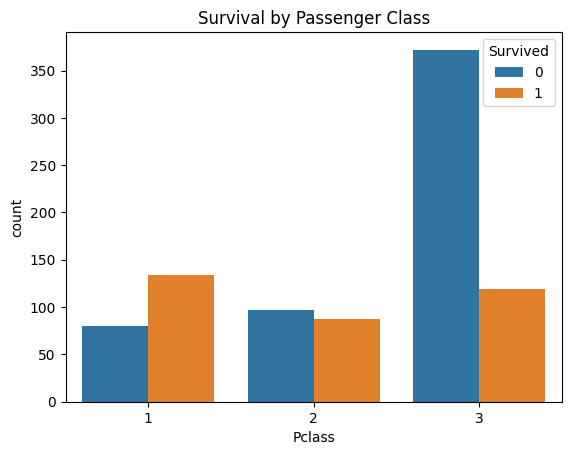

In [14]:
# Survival by Passenger Class
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()